Step 1: Install Libraries & Load Data

In [1]:
!pip install ultralytics
!pip install roboflow
import os
import cv2
import numpy as np
import pandas as pd
from ultralytics import YOLO
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt


def white_balance(img):
    """
    Standardizes lighting using the Gray World assumption.
    Required for accurate color extraction under different lights.
    """
    result = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    avg_a = np.average(result[:, :, 1])
    avg_b = np.average(result[:, :, 2])
    result[:, :, 1] = result[:, :, 1] - ((avg_a - 128) * (result[:, :, 0] / 255.0) * 1.1)
    result[:, :, 2] = result[:, :, 2] - ((avg_b - 128) * (result[:, :, 0] / 255.0) * 1.1)
    result = cv2.cvtColor(result, cv2.COLOR_LAB2BGR)
    return result




from roboflow import Roboflow
rf = Roboflow(api_key="C9gLQrmGWptAbZJRPfci")
project = rf.workspace("pramodya-priyasanka").project("urine-examination_-92ma9-5caxa")
version = project.version(2)
dataset = version.download("yolov8")


print(f"Dataset downloaded to: {dataset.location}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 131.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with


Extracting Dataset Version Zip to urine-examination_-2 in yolov8:: 100%|██████████| 616/616 [00:00<00:00, 1984.11it/s]

Dataset downloaded to: /content/urine-examination_-2


Step 2: Segmentation (Train YOLOv8)

In [2]:
model = YOLO('yolov8n.pt')
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    plots=True
)
metrics = model.val()
print(f"Map50-95: {metrics.box.map}")

Ultralytics 8.4.0 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/urine-examination_-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, 

Step 3: Feature Extraction Pipeline

In [3]:
def extract_color_features(image_path, model):
    """
    1. Detects pads using YOLO.
    2. Crops the pad image.
    3. Converts to HSV and calculates average color.
    """
    original_img = cv2.imread(image_path)
    balanced_img = white_balance(original_img)
    results = model(image_path)

    features = []
    for r in results:

        boxes = r.boxes
        for box in boxes:

            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            cls = int(box.cls[0])
            label_name = model.names[cls]


            pad_img = balanced_img[y1:y2, x1:x2]
            pad_img = cv2.GaussianBlur(pad_img, (3, 3), 0)
            hsv_img = cv2.cvtColor(pad_img, cv2.COLOR_BGR2HSV)
            avg_hsv = np.mean(hsv_img, axis=(0, 1))

            features.append({
                'pad_type': label_name,
                'h_avg': avg_hsv[0],
                's_avg': avg_hsv[1],
                'v_avg': avg_hsv[2]
            })

    return pd.DataFrame(features)

Step 4: SVC Model (Support Vector Machine)



In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix


def generate_realistic_data(n_samples=500):
    data = []
    for _ in range(n_samples):
        if np.random.rand() > 0.5:
            h = int(np.random.normal(100, 15))
            label = "Normal"
        else:
            h = int(np.random.normal(60, 15))
            label = "High"
        h = np.clip(h, 0, 179)
        s = np.random.randint(50, 255)
        v = np.random.randint(50, 255)

        data.append([h, s, v, label])

    return pd.DataFrame(data, columns=['h', 's', 'v', 'label'])

df_train = generate_realistic_data()
X = df_train[['h', 's', 'v']]
y = df_train['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
svm_classifier = SVC(kernel='linear', random_state=42)
svm_classifier.fit(X_train, y_train)


y_pred = svm_classifier.predict(X_test)

print("--- SVM Classification Accuracy ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

--- SVM Classification Accuracy ---
Accuracy: 92.00%

Confusion Matrix:
[[43  4]
 [ 4 49]]


Step 4.5: Upload & Visually Verify

Please upload a urine strip image to test:


Saving 4a77f75c2c1f2a65e373cf784fc015f_jpg.rf.438d274999c769c19d904a0a0f78e49b.jpg to 4a77f75c2c1f2a65e373cf784fc015f_jpg.rf.438d274999c769c19d904a0a0f78e49b.jpg

image 1/1 /content/4a77f75c2c1f2a65e373cf784fc015f_jpg.rf.438d274999c769c19d904a0a0f78e49b.jpg: 512x640 15 blocks, 1 pH, 39.9ms
Speed: 3.5ms preprocess, 39.9ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 640)

--- Analysis Results ---
Detected block: High (HSV: [ 26  17 192])
Detected block: High (HSV: [ 26  82 205])
Detected block: Normal (HSV: [164 106 163])
Detected block: High (HSV: [ 23  15 199])
Detected block: High (HSV: [ 24 112 208])
Detected block: High (HSV: [ 22  63 199])
Detected block: High (HSV: [ 25  70 203])
Detected block: High (HSV: [ 25  16 203])
Detected block: High (HSV: [ 22  84 205])
Detected block: High (HSV: [ 19  13 202])
Detected block: High (HSV: [ 28  11 201])
Detected block: High (HSV: [ 28  10 203])
Detected pH: High (HSV: [ 11 141 200])
Detected block: High (HSV: [ 59  11 194])

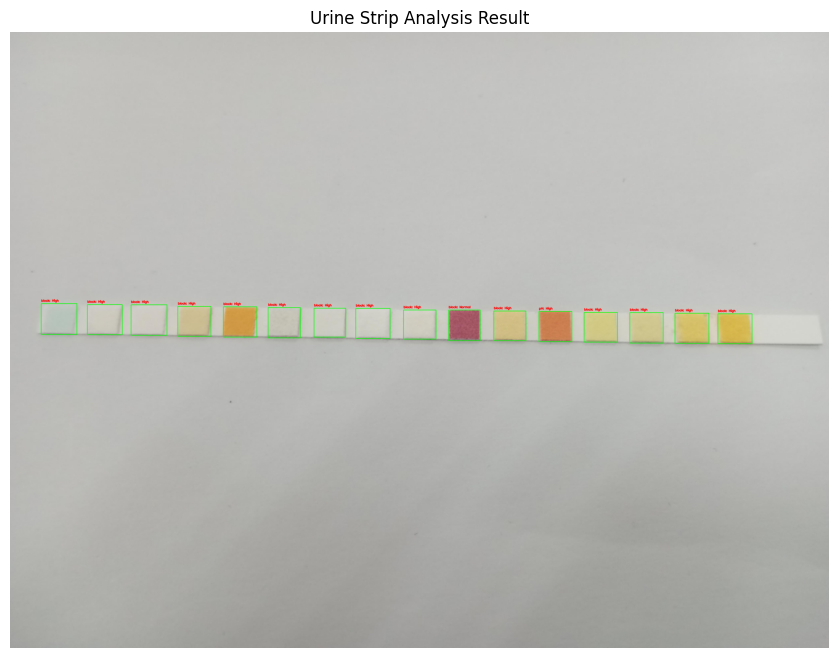

In [5]:
from google.colab import files
import matplotlib.pyplot as plt
import cv2
import numpy as np


print("Please upload a urine strip image to test:")
uploaded = files.upload()
filename = next(iter(uploaded))
img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
results = model(filename)
output_img = img_rgb.copy()
font = cv2.FONT_HERSHEY_SIMPLEX

print("\n--- Analysis Results ---")

found_pads = False
for r in results:
    boxes = r.boxes
    for box in boxes:
        found_pads = True
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        cls = int(box.cls[0])
        pad_name = model.names[cls]
        pad_crop = img[y1:y2, x1:x2]
        pad_crop = cv2.GaussianBlur(pad_crop, (3, 3), 0)
        hsv_crop = cv2.cvtColor(pad_crop, cv2.COLOR_BGR2HSV)
        avg_hsv = np.mean(hsv_crop, axis=(0, 1))
        input_df = pd.DataFrame([avg_hsv], columns=['h', 's', 'v'])
        diagnosis = svm_classifier.predict(input_df)[0]
        print(f"Detected {pad_name}: {diagnosis} (HSV: {avg_hsv.astype(int)})")
        cv2.rectangle(output_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        label_text = f"{pad_name}: {diagnosis}"
        cv2.putText(output_img, label_text, (x1, y1 - 10), font, 0.5, (255, 0, 0), 2)

if not found_pads:
    print("No urine strip pads were detected. Try an image with better lighting.")
plt.figure(figsize=(12, 8))
plt.imshow(output_img)
plt.axis('off')
plt.title("Urine Strip Analysis Result")
plt.show()

Step 5: The Final Application Logic

In [6]:
def analyze_urine_strip(image_path):
    """
    Full Pipeline:
    1. Preprocesses image (White Balance) - implicitly called inside extract_color_features
    2. Segments pads (YOLO)
    3. Extracts Color (HSV)
    4. Classifies Health Status (SVM)
    """
    pad_data = extract_color_features(image_path, model)
    if pad_data.empty:
        return {"error": "No strip detected. Please try a clearer image."}

    results = {}
    for index, row in pad_data.iterrows():
        pad_name = row['pad_type']

        features = [[row['h_avg'], row['s_avg'], row['v_avg']]]
        input_df = pd.DataFrame(features, columns=['h', 's', 'v'])
        diagnosis = svm_classifier.predict(input_df)[0]
        results[pad_name] = {
            "hsv_values": features[0],
            "diagnosis": diagnosis
        }

    return results

In [8]:
import joblib
from google.colab import files

# 1. Save the model to a file named 'svm_model.pkl'
joblib.dump(svm_classifier, 'svm_model.pkl')

# 2. Download the file to your local computer
files.download('svm_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>